# Stratified NLP Analysis - Topics by Category

This notebook analyzes topic models trained separately for each group (Issue, Company, Sub-issue, etc.).

Key Benefits:
- **Targeted insights**: Discover patterns specific to each category
- **Interpretability**: Understand topic nuances within context
- **Comparability**: Compare how different categories discuss similar issues
- **Actionability**: Find category-specific improvement areas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from tqdm import tqdm
import sys

sys.path.insert(0, '/Users/zhusizhen/Documents/project')

# Set up plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully")

Libraries loaded successfully


In [9]:
df = pd.read_csv('/Users/zhusizhen/Documents/project/data/results/complaints_with_topics_dual_stratified.csv')

In [14]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID',
       'issue_primary_topic', 'issue_confidence', 'issue_topic_0_prob',
       'issue_topic_1_prob', 'issue_topic_2_prob', 'issue_topic_3_prob',
       'issue_topic_4_prob', 'issue_topic_5_prob', 'issue_topic_6_prob',
       'issue_topic_7_prob', 'issue_topic_8_prob', 'issue_topic_9_prob',
       'company_primary_topic', 'company_confidence', 'company_topic_0_prob',
       'company_topic_1_prob', 'company_topic_2_prob', 'company_topic_3_prob',
       'company_topic_4_prob', 'company_topic_5_prob', 'company_topic_6_prob',
       'company_topic_7_prob', 'company_topic_8_prob', 'company_topic_9_prob'],
      dtype='object')

In [20]:
df['issue_primary_topic'].value_counts().head(20)

issue_primary_topic
0.0    37661
1.0    27470
8.0    18123
3.0    14650
6.0    14512
4.0    14326
5.0    14004
2.0    13384
7.0    12624
9.0     9256
Name: count, dtype: int64

## 1. Load Stratified Models Metadata

In [11]:
# Configure the groupby column (change this to analyze different stratifications)
GROUPBY_COLUMN = 'Issue'  # Can also be 'Company', 'Sub-issue', 'State', etc.

stratified_models_dir = Path('/Users/zhusizhen/Documents/project/data/stratified_models')
groupby_dir = stratified_models_dir / GROUPBY_COLUMN.replace(' ', '_')

# Load metadata
metadata_path = groupby_dir / 'models_index.json'
with open(metadata_path, 'r') as f:
    models_metadata = json.load(f)

print(f"Loaded {len(models_metadata)} trained models for groupby column: {GROUPBY_COLUMN}\n")

# Display metadata
for i, meta in enumerate(models_metadata[:10], 1):
    print(f"{i}. {meta['group_name']:<50} | Topics: {meta['n_topics']:<2} | Type: {meta['model_type']:<4} | Samples: {meta['n_samples']:>6,}")

Loaded 5 trained models for groupby column: Issue

1. Managing an account                                | Topics: 10 | Type: NMF  | Samples: 96,156
2. Closing an account                                 | Topics: 10 | Type: NMF  | Samples: 24,533
3. Problem with a lender or other company charging your account | Topics: 10 | Type: NMF  | Samples: 21,609
4. Problem caused by your funds being low             | Topics: 10 | Type: NMF  | Samples: 18,045
5. Opening an account                                 | Topics: 10 | Type: NMF  | Samples: 15,667


## 2. Load Original Dataset & Model Results

In [12]:
# Load original data for reference
csv_path = '/Users/zhusizhen/Documents/project/data/complaints-2026-05-17_11_33.csv'
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Show summary of groups
group_counts = df[GROUPBY_COLUMN].value_counts()
print(f"\nGroup distribution ({GROUPBY_COLUMN}):")
print(group_counts.head(10))

Dataset shape: (176942, 18)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Group distribution (Issue):
Issue
Managing an account                                                96156
Closing an account                                                 24533
Problem with a lender or other company charging your account       21609
Problem caused by your funds being low                             18045
Opening an account                                                 15667
Incorrect information on your report                                 338
Problem with a company's investigation into an existing problem      192
Improper use of your report                                          126
Problem with fraud

## 3. Extract Top Terms for Each Group

In [18]:
def get_top_terms_for_model(model, vectorizer, n_terms=10):
    """
    Extract top terms for each topic in a model.
    
    Returns: dict mapping topic_id -> list of (word, weight) tuples
    """
    feature_names = vectorizer.get_feature_names_out()
    topics = {}
    
    for topic_id, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_terms:][::-1]
        top_terms = [(feature_names[idx], topic[idx]) for idx in top_indices]
        topics[topic_id] = top_terms
    
    return topics

# Load models and extract top terms
group_topics = {}

for meta in tqdm(models_metadata, desc='Loading models'):
    group_name = meta['group_name']
    
    # Convert to absolute paths
    model_path = Path('/Users/zhusizhen/Documents/project') / meta['model_path']
    vec_path = Path('/Users/zhusizhen/Documents/project') / meta['vectorizer_path']
    
    try:
        model = joblib.load(model_path)
        vectorizer = joblib.load(vec_path)
        
        top_terms = get_top_terms_for_model(model, vectorizer, n_terms=10)
        group_topics[group_name] = {
            'metadata': meta,
            'topics': top_terms
        }
    except Exception as e:
        print(f"Error loading {group_name}: {e}")
        print(f"  Tried path: {model_path}")

print(f"\nSuccessfully loaded {len(group_topics)} model groups")

Loading models: 100%|██████████| 5/5 [00:01<00:00,  5.00it/s]


Successfully loaded 5 model groups


## 4. Display Topics by Group

In [19]:
# Show topics for first few groups
for i, (group_name, group_data) in enumerate(list(group_topics.items())[:3]):
    meta = group_data['metadata']
    topics = group_data['topics']
    
    print(f"\n{'='*80}")
    print(f"GROUP: {group_name}")
    print(f"Model: {meta['model_type']} with {meta['n_topics']} topics")
    print(f"Samples: {meta['n_samples']:,} | Score: {meta['score']:.4f}")
    print(f"{'='*80}")
    
    for topic_id, terms in topics.items():
        print(f"\nTopic {topic_id}:")
        terms_str = ' | '.join([f"{word}({weight:.2f})" for word, weight in terms[:7]])
        print(f"  {terms_str}")


GROUP: Managing an account
Model: NMF with 10 topics
Samples: 96,156 | Score: 272.6230

Topic 0:
  xxxx(11.45) | xxxxxxxx(0.56) | payment(0.29) | number(0.26) | send(0.25) | receive(0.23) | bank(0.21)

Topic 1:
  account(6.07) | money(1.90) | access(1.72) | transfer(1.64) | tell(1.54) | bank(1.53) | close(1.44)

Topic 2:
  capital(3.00) | deposit(2.10) | fund(1.36) | direct(1.28) | technical(1.25) | employer(1.23) | uphold(1.21)

Topic 3:
  card(3.51) | transaction(3.33) | claim(2.68) | dispute(2.12) | debit(1.89) | bank(1.79) | report(1.53)

Topic 4:
  fargo(4.46) | wells(4.39) | claim(0.40) | account(0.32) | fraud(0.19) | complaint(0.17) | close(0.15)

Topic 5:
  chase(6.15) | claim(0.35) | number(0.30) | account(0.29) | branch(0.26) | fraud(0.22) | verify(0.22)

Topic 6:
  check(6.32) | deposit(2.71) | hold(2.24) | bank(2.01) | fund(1.78) | available(1.05) | release(0.96)

Topic 7:
  fee(4.41) | charge(3.41) | overdraft(2.02) | account(0.85) | balance(0.64) | payment(0.55) | pay(0.

## 5. Visualize Topics for Each Group

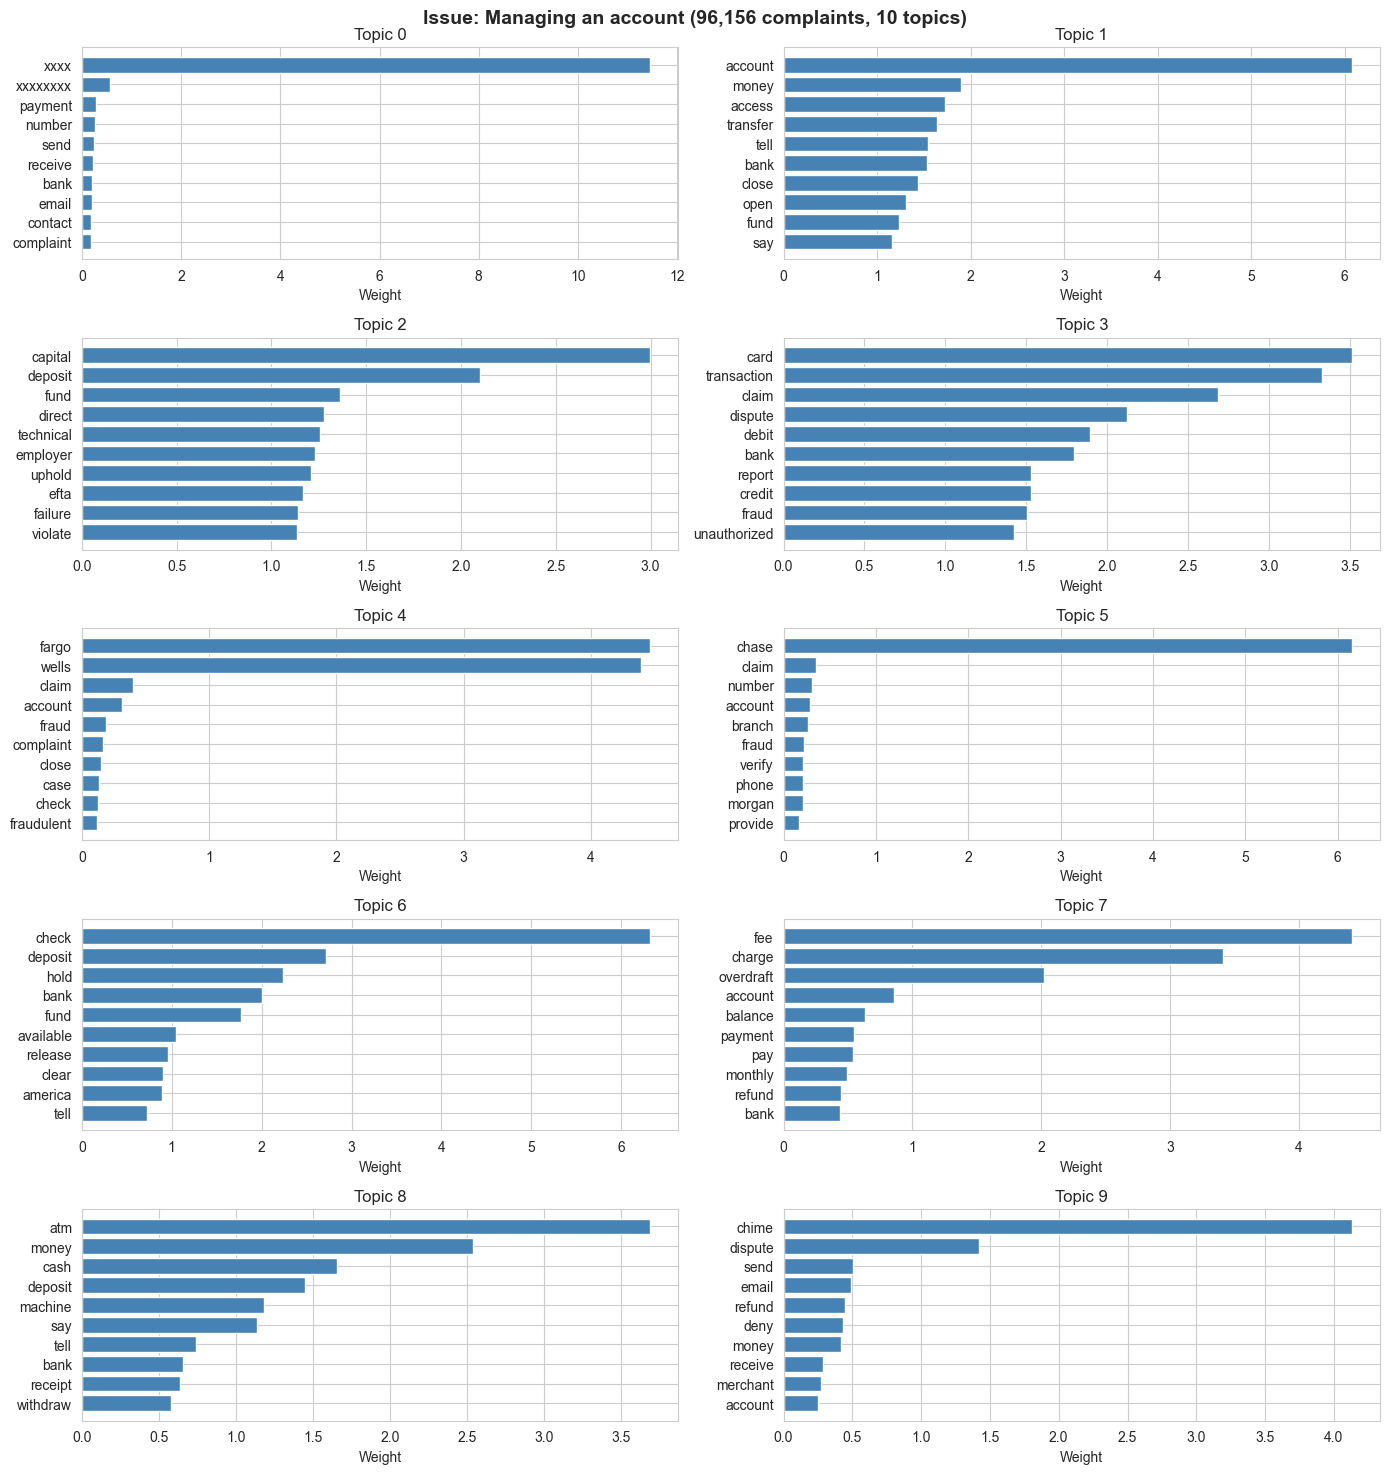

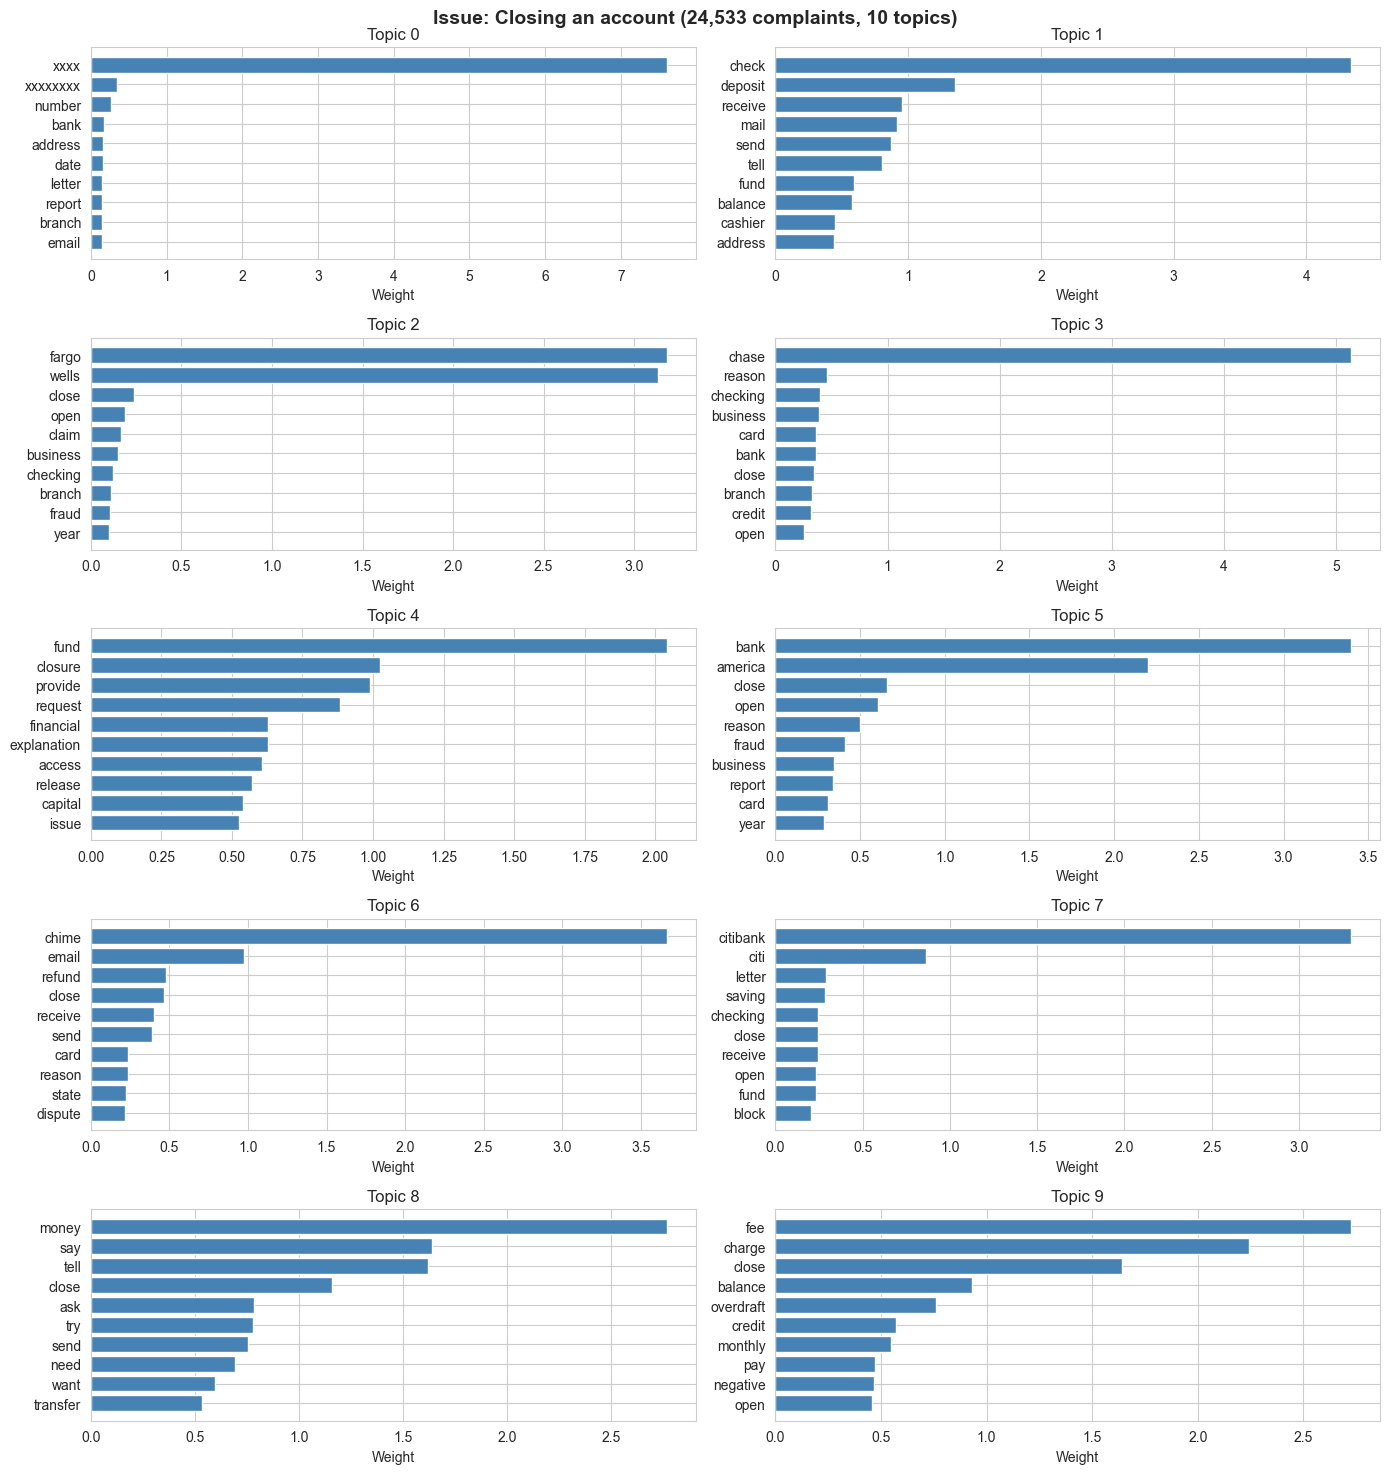

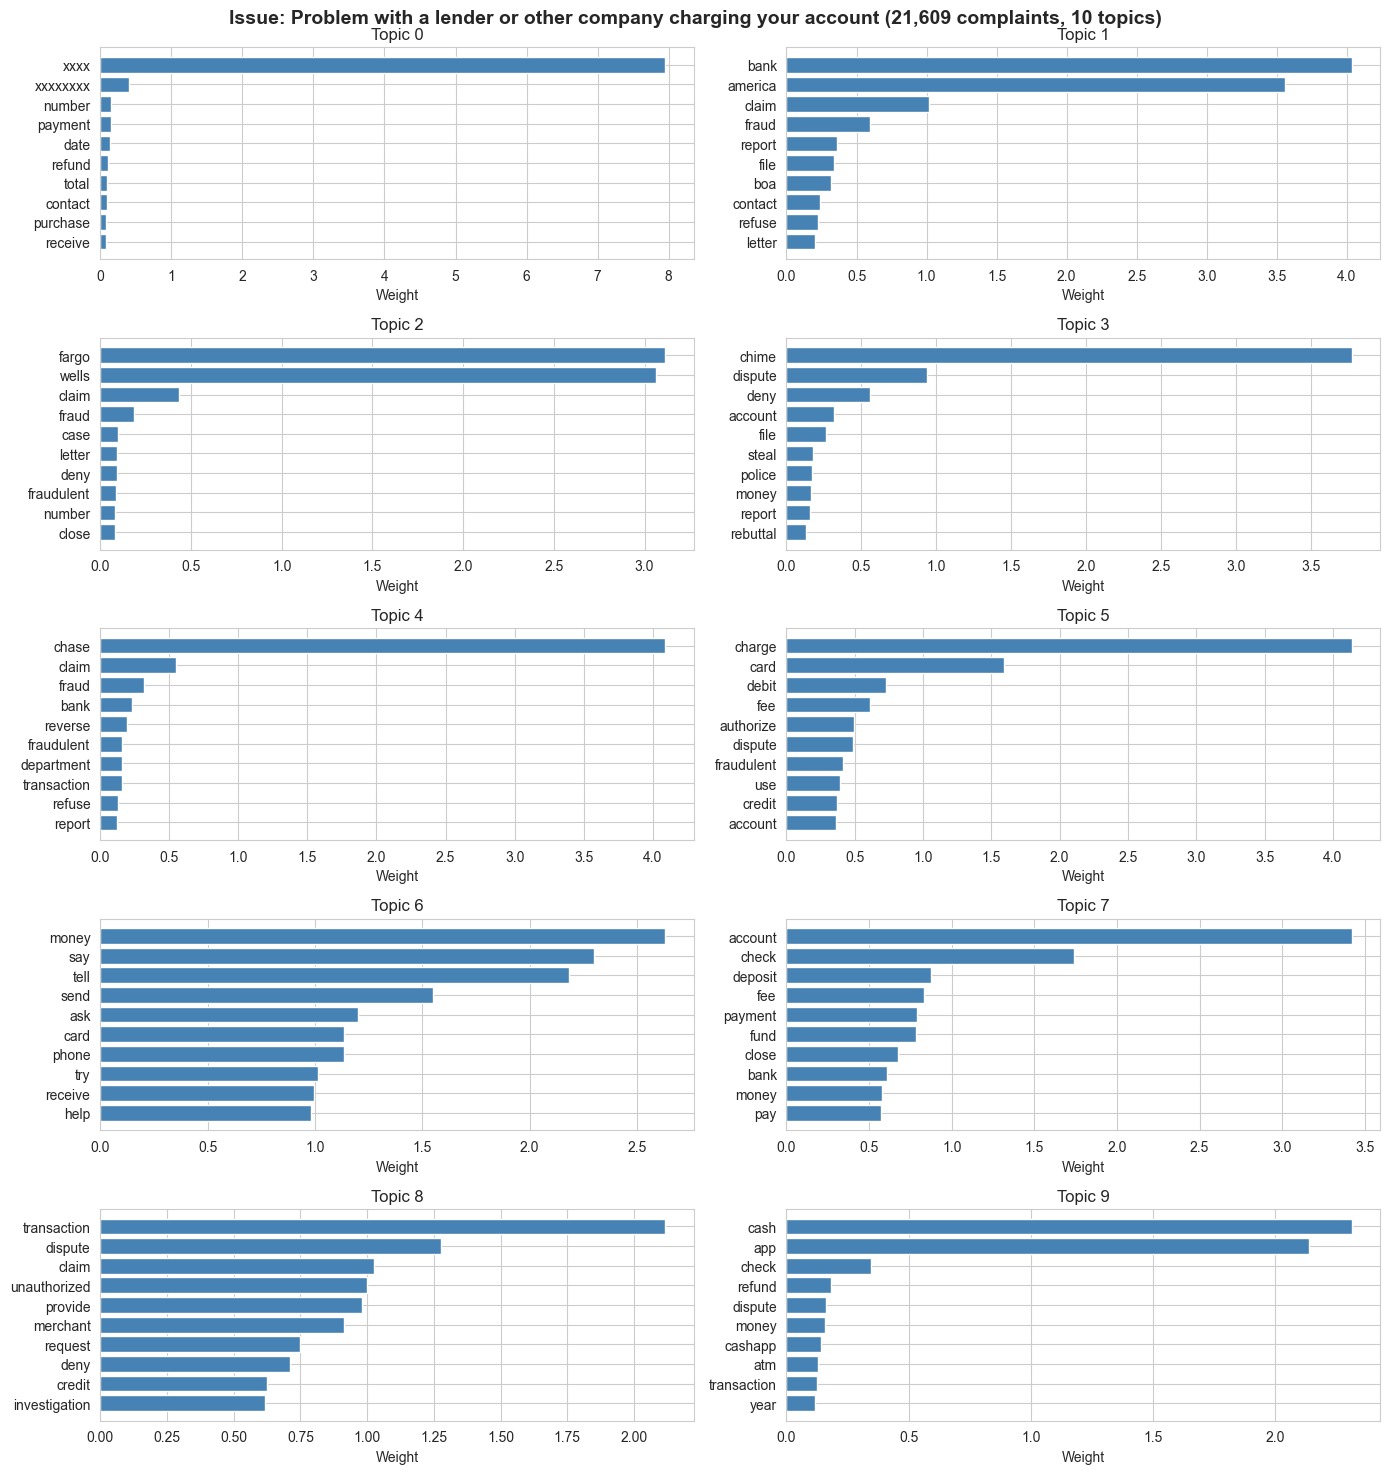

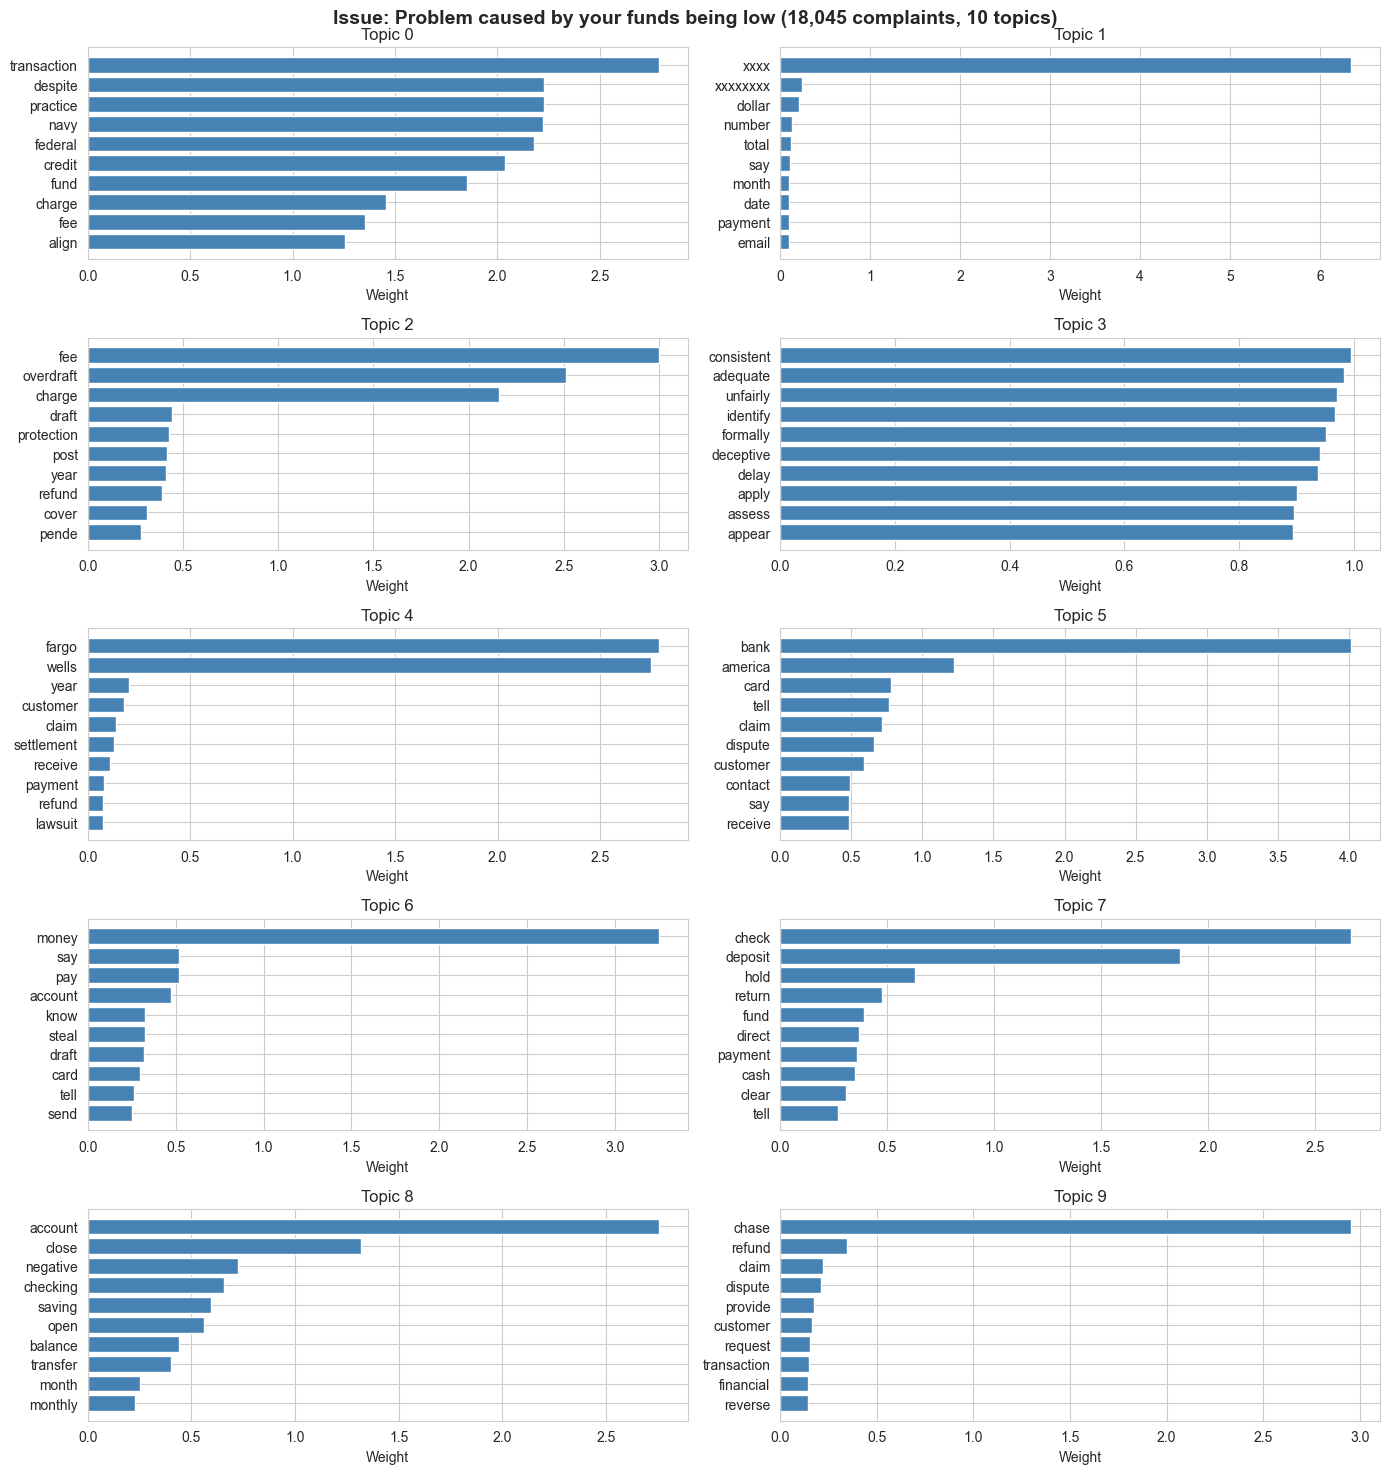

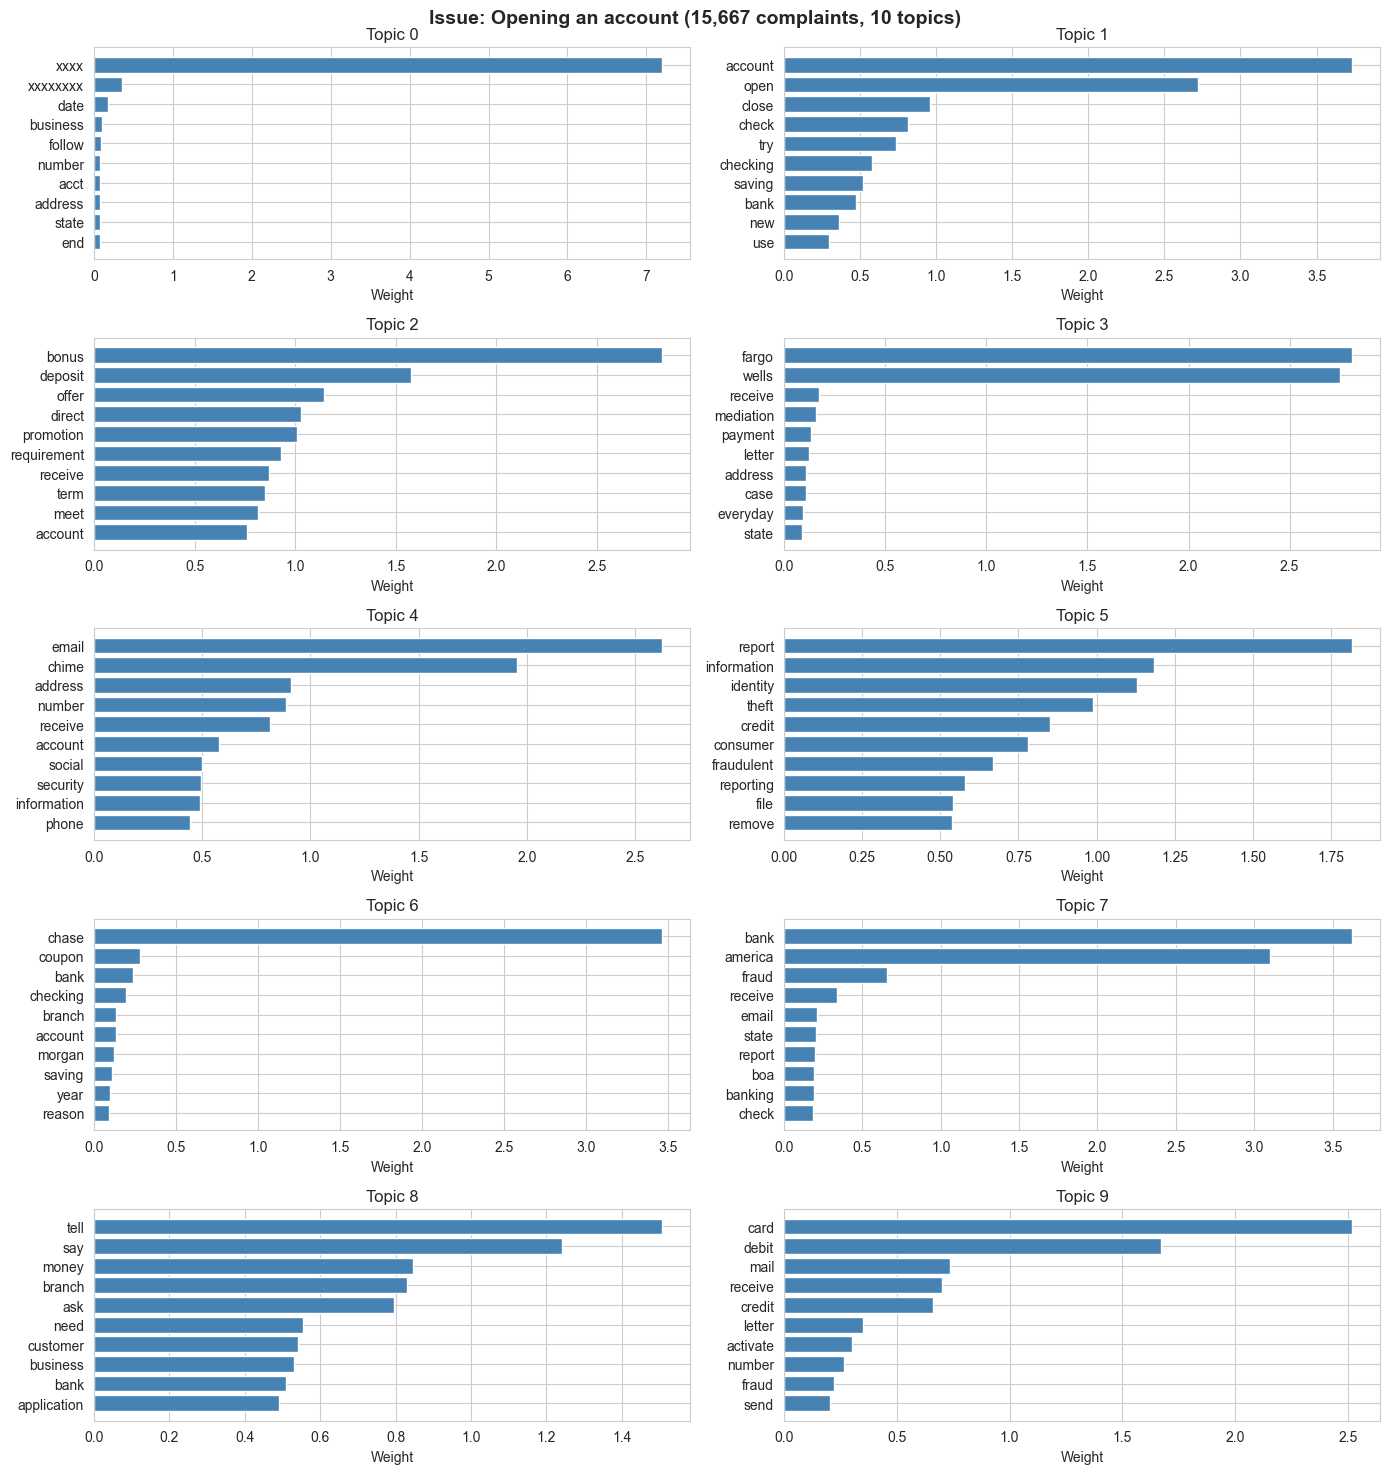

In [20]:
# Create visualization for each group (first 5)
for group_name, group_data in list(group_topics.items())[:5]:
    meta = group_data['metadata']
    topics = group_data['topics']
    
    n_topics = len(topics)
    cols = 2
    rows = (n_topics + 1) // 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3*rows))
    axes = axes.flatten()
    
    for topic_id, terms in topics.items():
        ax = axes[topic_id]
        
        words = [w for w, _ in terms[:10]]
        weights = [wt for _, wt in terms[:10]]
        
        ax.barh(words, weights, color='steelblue')
        ax.set_xlabel('Weight')
        ax.set_title(f'Topic {topic_id}')
        ax.invert_yaxis()
    
    # Hide extra subplots
    for idx in range(n_topics, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f"{GROUPBY_COLUMN}: {group_name} ({meta['n_samples']:,} complaints, {meta['n_topics']} topics)",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Compare Topic Vocabularies Across Groups

In [21]:
# Extract all unique words across all groups and their importance
word_importance = {}  # word -> {group_name -> avg_weight}

for group_name, group_data in group_topics.items():
    topics = group_data['topics']
    for topic_id, terms in topics.items():
        for word, weight in terms:
            if word not in word_importance:
                word_importance[word] = {}
            word_importance[word][group_name] = max(
                word_importance[word].get(group_name, 0), weight
            )

# Find words that appear frequently across groups
word_group_count = {w: len(groups) for w, groups in word_importance.items()}
common_words = sorted(word_group_count.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"Top 20 Words Appearing Across Groups:")
print(f"{'Word':<20} {'Groups':<10}")
print("-" * 30)
for word, count in common_words:
    print(f"{word:<20} {count:<10}")

Top 20 Words Appearing Across Groups:
Word                 Groups    
------------------------------
xxxx                 5         
xxxxxxxx             5         
number               5         
send                 5         
receive              5         
bank                 5         
money                5         
tell                 5         
close                5         
say                  5         
deposit              5         
card                 5         
credit               5         
fargo                5         
wells                5         
check                5         
chase                5         
america              5         
payment              4         
email                4         


## 7. Sample Complaints from Each Topic in Each Group

In [23]:
def get_sample_complaints_for_group(group_name, model, vectorizer, df, n_samples=2):
    """
    Get sample complaints for each topic in a group.
    """
    from utils.preprocessing import preprocess_batch
    
    # Filter data for this group
    group_df = df[df[GROUPBY_COLUMN] == group_name].copy()
    
    # Preprocess texts
    processed = group_df['Consumer complaint narrative'].apply(
        lambda x: ' '.join(preprocess_batch([str(x)])[0]) if pd.notna(x) else ''
    )
    
    # Vectorize
    X = vectorizer.transform(processed)
    
    # Get topic predictions
    topic_dist = model.transform(X)
    primary_topics = topic_dist.argmax(axis=1)
    
    samples = {}  # topic_id -> list of sample texts
    
    for topic_id in range(model.n_components_):
        topic_indices = np.where(primary_topics == topic_id)[0]
        if len(topic_indices) == 0:
            samples[topic_id] = []
        else:
            # Get highest confidence samples
            confidences = topic_dist[topic_indices, topic_id]
            top_indices = topic_indices[confidences.argsort()[-n_samples:][::-1]]
            samples[topic_id] = group_df.iloc[top_indices]['Consumer complaint narrative'].tolist()
    
    return samples

# Get samples for first group
first_group = list(group_topics.keys())[0]
first_meta = group_topics[first_group]['metadata']

print(f"Fetching sample complaints for: {first_group}")

# Convert to absolute paths
model_path = Path('/Users/zhusizhen/Documents/project') / first_meta['model_path']
vec_path = Path('/Users/zhusizhen/Documents/project') / first_meta['vectorizer_path']

model = joblib.load(model_path)
vectorizer = joblib.load(vec_path)

samples = get_sample_complaints_for_group(first_group, model, vectorizer, df, n_samples=1)

print(f"\n{'='*80}")
print(f"SAMPLE COMPLAINTS - {first_group}")
print(f"{'='*80}")

for topic_id, complaints in samples.items():
    if complaints:
        print(f"\nTopic {topic_id}:")
        complaint = complaints[0][:300] + "..." if len(complaints[0]) > 300 else complaints[0]
        print(f"  {complaint}")

Fetching sample complaints for: Managing an account


/Users/zhusizhen/Documents/project/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



SAMPLE COMPLAINTS - Managing an account

Topic 0:
  Disputing with Bank Of America for fraudulent charges for months.  They have not given me a refund for my charges.  It is going to be a year and they have not tried to help me in this matter.

Starting:

- XXXX XXXX XXXX from the company called XXXX XXXX XXXX" for the amount XXXX XXXX XXXX XXXXXXXX ...

Topic 1:
  I got denied access to my accounts, they were closed I had money in the account nothing was sent to me after they closed my accounts. When asked why my accounts were closed they said they couldnt tell me and hung up the phone. I continue to receive statements from my accounts and saying I have acces...

Topic 2:
  Hi, I am a longtime customer of Capital One Bank and I am filing a complaint with the CFPB regarding Capital One 's failure to deposit my direct deposit from my employer and any other incoming deposits. Capital One has cited technical issues, which may violate the Electronic Funds Transfer Act ( EFT...

Topic 3:
 

## 8. Summary Statistics

In [24]:
# Create summary statistics
summary = []

for group_name, group_data in group_topics.items():
    meta = group_data['metadata']
    summary.append({
        GROUPBY_COLUMN: group_name,
        'Model Type': meta['model_type'],
        'Topics': meta['n_topics'],
        'Complaints': meta['n_samples'],
        'Score': meta['score']
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values('Complaints', ascending=False)

print(f"\nSTRATIFIED MODELS SUMMARY (Grouped by {GROUPBY_COLUMN})\n")
print(summary_df.to_string(index=False))
print(f"\nTotal Groups: {len(summary_df)}")
print(f"Total Complaints Covered: {summary_df['Complaints'].sum():,}")


STRATIFIED MODELS SUMMARY (Grouped by Issue)

                                                       Issue Model Type  Topics  Complaints      Score
                                         Managing an account        NMF      10       96156 272.623049
                                          Closing an account        NMF      10       24533 139.708141
Problem with a lender or other company charging your account        NMF      10       21609 127.855385
                      Problem caused by your funds being low        NMF      10       18045 100.212056
                                          Opening an account        NMF      10       15667 109.214701

Total Groups: 5
Total Complaints Covered: 176,010
